In [1]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

In [2]:
data = pd.read_csv(r"C:\Users\A susmitha\Downloads\customer_shopping_data.csv")

# Basic checks

In [3]:
data.head()

,invoice_no,customer_id,gender,age,category,quantity,price,payment_method,invoice_date,shopping_mall
0,I138884,C241288,Female,28,Clothing,5,1500.40,Credit Card,5/8/2022,Kanyon
1,I317333,C111565,Male,21,Shoes,3,1800.51,Debit Card,12/12/2021,Forum Istanbul
2,I127801,C266599,Male,20,Clothing,1,300.08,Cash,9/11/2021,Metrocity
3,I173702,C988172,Female,66,Shoes,5,3000.85,Credit Card,16/05/2021,Metropol AVM
4,I337046,C189076,Female,53,Books,4,60.60,Cash,24/10/2021,Kanyon


In [4]:
data.describe()

,age,quantity,price
count,99457.000000,99457.000000,99457.000000
mean,43.427089,3.003429,689.256321
std,14.990054,1.413025,941.184567
min,18.000000,1.000000,5.230000
25%,30.000000,2.000000,45.450000
50%,43.000000,3.000000,203.300000
75%,56.000000,4.000000,1200.320000
max,69.000000,5.000000,5250.000000


In [5]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 99457 entries, 0 to 99456
Data columns (total 10 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   invoice_no      99457 non-null  object 
 1   customer_id     99457 non-null  object 
 2   gender          99457 non-null  object 
 3   age             99457 non-null  int64  
 4   category        99457 non-null  object 
 5   quantity        99457 non-null  int64  
 6   price           99457 non-null  float64
 7   payment_method  99457 non-null  object 
 8   invoice_date    99457 non-null  object 
 9   shopping_mall   99457 non-null  object 
dtypes: float64(1), int64(2), object(7)
memory usage: 7.6+ MB


# Data Cleaning

In [6]:
data.isnull().sum()

invoice_no        0
customer_id       0
gender            0
age               0
category          0
quantity          0
price             0
payment_method    0
invoice_date      0
shopping_mall     0
dtype: int64

In [7]:
# Convert invoice_date Column
data['invoice_date'] = pd.to_datetime(data['invoice_date'],dayfirst=True)

# Feature Engineering

In [8]:
# Create Month Column
data['month'] = data['invoice_date'].dt.month_name()

In [9]:
#Create Year Column
data['year'] = data['invoice_date'].dt.year

In [10]:
# Create Total Amount Column
data['total_amount'] = data['quantity'] * data['price']

# Customer Analysis

#### Top Customers

In [11]:
top_customers = data.groupby('customer_id')['total_amount'].sum().sort_values(ascending=False)

print(top_customers.head(10))

customer_id
C137763    26250.0
C699580    26250.0
C110600    26250.0
C110625    26250.0
C211345    26250.0
C139344    26250.0
C700083    26250.0
C291511    26250.0
C291627    26250.0
C164347    26250.0
Name: total_amount, dtype: float64


#### Total Sales

In [12]:
total_sales = data['total_amount'].sum()

print("Total Sales:", total_sales)

Total Sales: 251505794.25000003


#### Most Popular Category

In [13]:
top_category = data.groupby('category')['quantity'].sum().sort_values(ascending=False)

print(top_category)

category
Clothing           103558
Cosmetics           45465
Food & Beverage     44277
Toys                30321
Shoes               30217
Technology          15021
Books               14982
Souvenir            14871
Name: quantity, dtype: int64


#### Sales by Gender

In [14]:
gender_sales = data.groupby('gender')['total_amount'].sum()

print(gender_sales)

gender
Female    1.502071e+08
Male      1.012987e+08
Name: total_amount, dtype: float64


#### Sales by Payment Method

In [15]:
monthly_sales = data.groupby('month')['total_amount'].sum()

print(monthly_sales)

month
April        18715685.98
August       19282361.29
December     19455085.64
February     26625090.10
January      28891525.59
July         20378722.63
June         18933775.30
March        21956191.33
May          19719331.10
November     18207139.95
October      20545090.43
September    18795794.91
Name: total_amount, dtype: float64


#### Shopping Mall Performance

In [16]:
mall_sales = data.groupby('shopping_mall')['total_amount'].sum().sort_values(ascending=False)

print(mall_sales)

shopping_mall
Mall of Istanbul     50872481.68
Kanyon               50554231.10
Metrocity            37302787.33
Metropol AVM         25379913.19
Istinye Park         24618827.68
Zorlu Center         12901053.82
Cevahir AVM          12645138.20
Viaport Outlet       12521339.72
Emaar Square Mall    12406100.29
Forum Istanbul       12303921.24
Name: total_amount, dtype: float64


# Create Charts

### Category Sales Chart

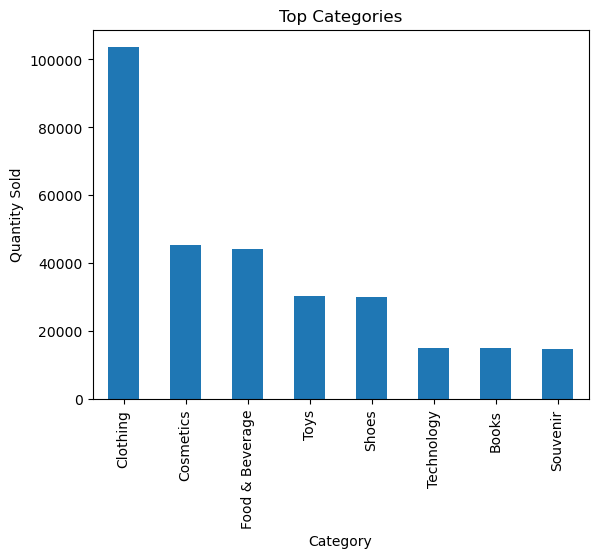

In [17]:
top_category.plot(kind='bar')

plt.title("Top Categories")
plt.xlabel("Category")
plt.ylabel("Quantity Sold")

plt.show()

### Monthly Sales Trend

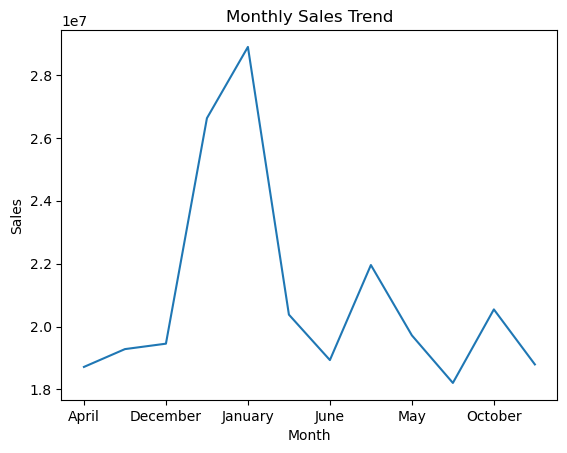

In [18]:
monthly_sales.plot(kind='line')

plt.title("Monthly Sales Trend")
plt.xlabel("Month")
plt.ylabel("Sales")

plt.show()

### Gender Sales Pie Chart

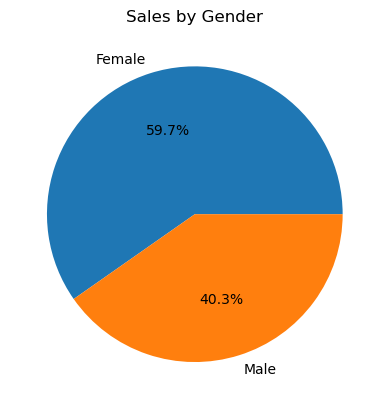

In [19]:
gender_sales.plot(kind='pie', autopct='%1.1f%%')

plt.title("Sales by Gender")

plt.ylabel('')

plt.show()

# Export Cleaned Data

In [21]:
data.to_csv("cleaned_customer_data.csv", index=False)